In [1]:
import numpy as np
import pandas as pd
import cvxpy as cvx
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [2]:
df = pd.read_csv("DailyReturns.csv", index_col='Date', parse_dates=True)
df.head()

,AAPL,AMZN,BRK-B,GOOG,LLY,META,MSFT,NVDA,TSM
Date,,,,,,,,,
2015-01-02,-0.514999,-0.203000,-2.330002,-0.209425,0.290001,-0.130005,0.099998,0.00000,-0.170000
2015-01-05,-0.510000,-0.241000,-1.809998,-0.468214,-0.360001,-0.790001,-0.039997,-0.00850,-0.400000
2015-01-06,-0.070000,-0.347501,-0.800003,-0.650215,-0.199997,-1.080002,-0.730000,-0.01575,0.040001
2015-01-07,0.137501,0.046000,0.940002,-0.294191,-0.799995,-0.610001,0.250000,-0.00475,0.080000
2015-01-08,0.664999,0.007000,0.769989,0.233858,0.870003,1.440002,0.840000,0.01250,0.119999


In [3]:
df.describe()

,AAPL,AMZN,BRK-B,GOOG,LLY,META,MSFT,NVDA,TSM
count,2431.000000,2431.000000,2431.000000,2431.000000,2431.000000,2431.000000,2431.000000,2431.000000,2431.000000
mean,0.075099,-0.032573,-0.043595,0.055229,0.080576,0.119893,0.047421,0.004179,-0.032855
std,1.573958,1.791163,2.284660,1.247087,4.367827,3.896041,2.827448,0.842414,1.271779
min,-7.080002,-7.990494,-12.859985,-6.527496,-58.130005,-23.260010,-15.670013,-9.020004,-8.589996
25%,-0.403749,-0.707001,-1.139984,-0.399502,-0.950008,-1.465012,-0.820000,-0.077125,-0.400001
50%,0.049999,0.000000,-0.010010,0.044006,0.099998,0.090027,0.070004,0.002250,0.009998
75%,0.548752,0.674004,1.104996,0.570000,1.149998,1.774994,1.000000,0.095875,0.375004
max,13.500000,11.520508,15.200012,7.673492,31.679993,28.309967,22.079987,8.389999,14.089996


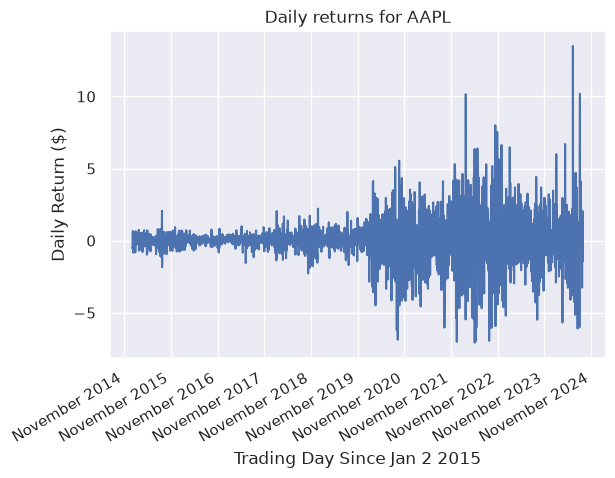

In [4]:
ticker = 'AAPL'
ax = sns.lineplot(y=ticker, x=df.index, data=df)
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%B %Y"))  # e.g., "January 2026"
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
plt.gcf().autofmt_xdate()
plt.ylabel("Daily Return ($)")
plt.xlabel("Trading Day Since Jan 2 2015")
plt.title(f"Daily returns for {ticker}")
plt.show()

In [5]:
Sigma = df.cov().to_numpy()
r = df.mean().to_numpy()
n = df.shape[1]

In [6]:
#everythign below is in class
x = cvx.Variable(n, nonneg=True)
obj = cvx.Minimize(.5*cvx.quad_form(x, Sigma))
cons = [r.T @ x >= .05, cvx.sum(x)==1.]
prob = cvx.Problem(obj, cons)
prob.solve(verbose=True)

(CVXPY) Jul 23 01:48:43 PM: Your problem has 9 variables, 2 constraints, and 0 parameters.


                                     CVXPY                                     
                                     v1.9.2                                    


(CVXPY) Jul 23 01:48:43 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jul 23 01:48:43 PM: DCP verification time: 0.0045 seconds.
(CVXPY) Jul 23 01:48:43 PM: Expression tree has 4 nodes.
(CVXPY) Jul 23 01:48:43 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jul 23 01:48:43 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jul 23 01:48:43 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jul 23 01:48:43 PM: Compiling problem (target solver=OSQP).
(CVXPY) Jul 23 01:48:43 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> EliminateZeroSized -> ConeMatrixStuffing -> OSQP
(CVXPY) Jul 23 01:48:43 PM: Applying reduction Dcp2Cone
(CVXPY) Jul 23 01:48:43 PM: Applying reduction CvxAttr2Constr
(CVXPY) Jul 23 01:48:43 PM: Applying reduction EliminateZeroSized
(CVXPY) Jul 23 01:48:43 PM: Applying reduction ConeMatrixStuffin

-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 9, constraints m = 11
          nnz(P) + nnz(A) = 72
settings: algebra = Built-in,
          OSQPInt = 4 bytes, OSQPFloat = 8 bytes,
          linear system solver = QDLDL v0.1.8,
          eps_abs = 1.0e-05, eps_rel = 1.0e-05,
          eps_prim_inf = 1.0e-04, eps_

np.float64(0.5469090958162794)

In [7]:
#demo: how to use cvxpy's parameters

In [8]:
x = cvx.Variable(n, nonneg=True)
return_rate = cvx.Parameter()
obj = cvx.Minimize(.5*cvx.quad_form(x, Sigma))
cons = [r.T @ x >= return_rate, cvx.sum(x)==1.]
prob = cvx.Problem(obj, cons)

In [11]:
#%%timeit -n 1 -r 1
#time this block
rates = np.linspace(-.10, .2, 1000)
variances = np.empty(rates.size)
for i, rate in enumerate(rates):
    return_rate.value = rate
    prob.solve()
    if prob.status == 'optimal':
        variances[i] = prob.value
    else:
        variances[i] = np.inf    
#we are solving many optimization problems in this time!

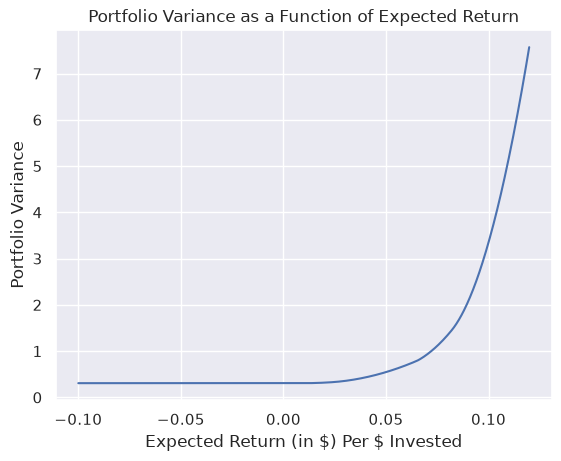

In [12]:
plt.plot(rates, variances)
plt.xlabel('Expected Return (in \\$) Per $ Invested')
plt.ylabel('Portfolio Variance')
plt.title("Portfolio Variance as a Function of Expected Return")
plt.show()
